# Proyek Analisis Data: PRSA Data Changping dan PRSA Data Dongsi
- **Nama:** Favian Hilmi Putradifa
- **Email:** favianhilmi11@gmail.com
- **ID Dicoding:** A180YBM165

## Menentukan Pertanyaan Bisnis

- Pada jam berapa kualitas udara di Kota Changping dan Dongsi memburuk dari biasanya?
- Bagaimana pola perubahan kualitas udara berdasarkan musim atau hari dalam seminggu?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Wrangling

### Gathering Data

In [ ]:
# Dataset yang digunakan
changping_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PRSA_Data_Changping.csv", sep=";", low_memory=False)
dongsi_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PRSA_Data_Dongsi.csv", sep=";", low_memory=False)


df_combined = pd.concat([changping_df, dongsi_df], ignore_index=True)

df_combined["datetime"] = pd.to_datetime(df_combined[["year", "month", "day", "hour"]])

print(df_combined.info())
print(df_combined.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70128 entries, 0 to 70127
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   No        70128 non-null  int64         
 1   year      70128 non-null  int64         
 2   month     70128 non-null  int64         
 3   day       70128 non-null  int64         
 4   hour      70128 non-null  int64         
 5   PM2.5     68604 non-null  float64       
 6   PM10      68993 non-null  float64       
 7   SO2       68837 non-null  object        
 8   NO2       67860 non-null  object        
 9   CO        65410 non-null  float64       
 10  O3        68860 non-null  object        
 11  TEMP      70055 non-null  object        
 12  PRES      70058 non-null  object        
 13  DEWP      70055 non-null  float64       
 14  RAIN      70057 non-null  float64       
 15  wd        69910 non-null  object        
 16  WSPM      70071 non-null  float64       
 17  station   70

### **1. Dataset Overview**  
Menggunakan 2 dataset kualitas udara dari 2 lokasi berbeda:
- Dataset pengukuran kualitas udara Kota Changping
- Dataset pengukuran kualitas udara Kota Dongsi

### **2. Konversi kolom waktu menjadi Datetime**
Dataset memiliki informasi waktu dalam beberapa kolom (year, month, day, hour). Untuk mempermudah analisis, kolom tersebut dikonversi menjadi 1 kolom datetime.

### Assessing Data

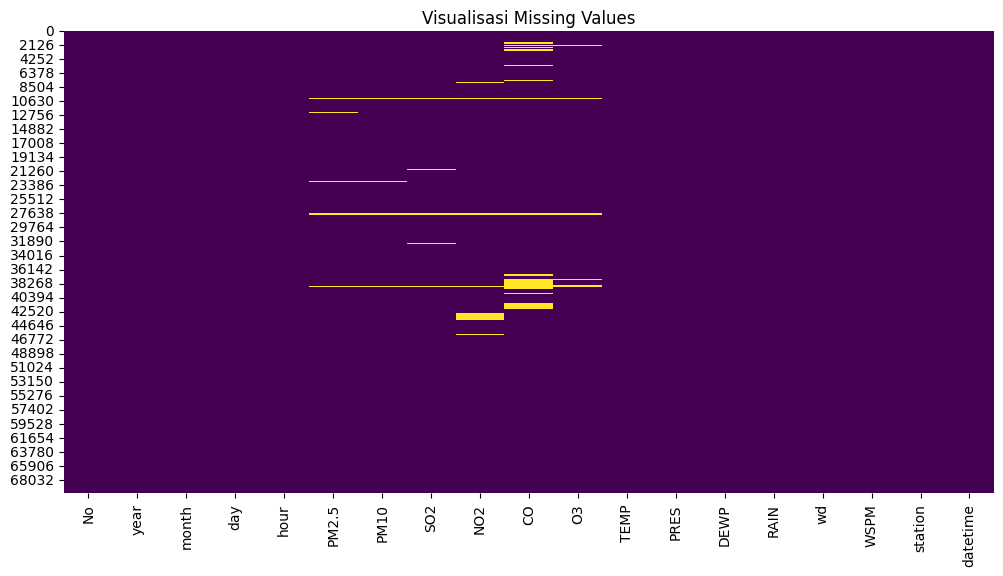

Missing Value Checking
PM2.5    1524
PM10     1135
SO2      1291
NO2      2268
CO       4718
O3       1268
TEMP       73
PRES       70
DEWP       73
WSPM       57
dtype: int64


In [ ]:
selected_columns = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "WSPM" ]

existing_columns = [col for col in selected_columns if col in df_combined.columns]

plt.figure(figsize=(12, 6))
sns.heatmap(df_combined.isnull(), cmap="viridis", cbar=False)
plt.title("Visualisasi Missing Values")
plt.show()

print("Missing Value Checking")
print(df_combined[existing_columns].isnull().sum())

In [ ]:
print("Duplicate Data Checking")
print(df_combined.duplicated().sum())

Duplicate Data Checking
0


Detect Outlier dengan IQR
Kolom yang ada dalam DataFrame: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']


Cek tipe data
 PM2.5    float64
PM10     float64
SO2       object
NO2       object
CO       float64
O3        object
TEMP      object
PRES      object
DEWP     float64
WSPM     float64
dtype: object
PM2.5    float64
PM10     float64
SO2       object
NO2       object
CO       float64
O3        object
TEMP      object
PRES      object
DEWP     float64
WSPM     float64
dtype: object


setelah processing
 PM2.5    float64
PM10     float64
SO2      float64
NO2      float64
CO       float64
O3       float64
TEMP     float64
PRES     float64
DEWP     float64
WSPM     float64
dtype: object


Cek Outlier pada Dataframe
PM2.5    3227
PM10     2577
SO2      5697
NO2      2532
CO       4550
O3       3580
TEMP        4
PRES        0
DEWP        0
WSPM     4446
dtype: int64


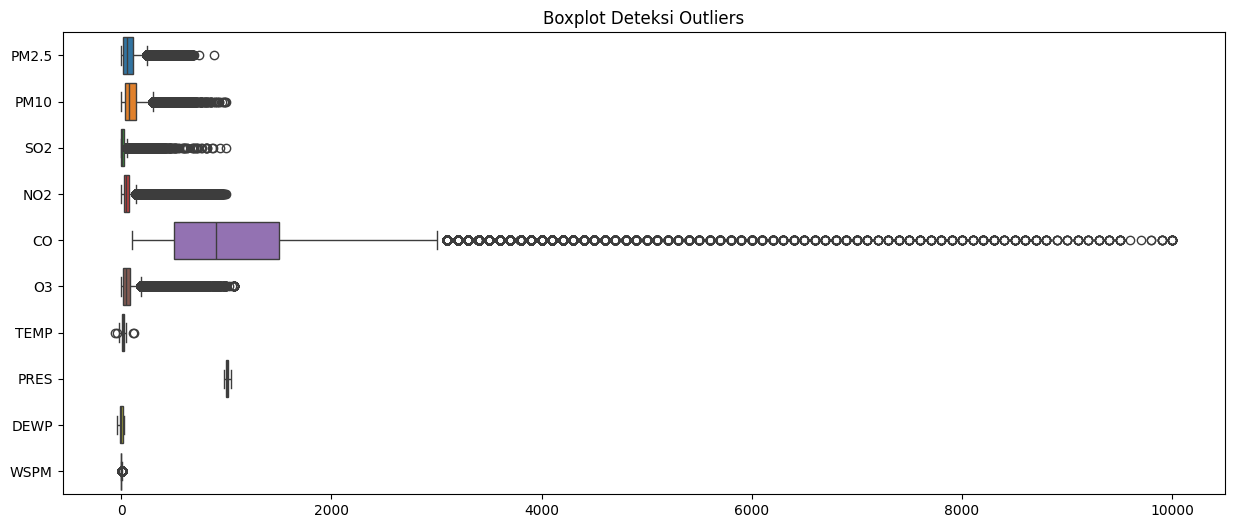

In [ ]:
print("Detect Outlier dengan IQR")

selected_columns = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "WSPM" ]
existing_columns = [col for col in selected_columns if col in df_combined.columns]
print(f"Kolom yang ada dalam DataFrame: {existing_columns}")
print("\n")

# Cek tipe data seluruh kolom
print("Cek tipe data\n",df_combined[existing_columns].dtypes)
print(df_combined[existing_columns].dtypes)
df_combined[existing_columns] = df_combined[existing_columns].apply(pd.to_numeric, errors='coerce')
print("\n")
print("setelah processing\n",df_combined[existing_columns].dtypes)
print("\n")

# Cek outlier
print("Cek Outlier pada Dataframe")
Q1 = df_combined[existing_columns].quantile(0.25)
Q3 = df_combined[existing_columns].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_combined[existing_columns] < (Q1 - 1.5 * IQR)) |
            (df_combined[existing_columns] > (Q3 + 1.5 * IQR))).sum()

print(outliers)


plt.figure(figsize=(15, 6))
sns.boxplot(data=df_combined[existing_columns].select_dtypes(include=['number']), orient='h')
plt.title("Boxplot Deteksi Outliers")
plt.show()


**Insight:**

### **1. Pengecekan Missing Value**  
- Dilakukan untuk mengetahui apakah ada nilai yang hilang (Nan)
- Dicek menggunakan function `".isnull().sum()"`

### **2. Pengecekan Data Duplikat**  
- Dilakukan untuk mengetahui data duplikat yang dapat mempengaruhi hasil analisis
- Dicek menggunakan function `".duplicated().sum()"`

### **3. Pengecekan Outlier**  
Dilakukan untuk memastikan tidak ada nilai ekstrem, menggunakan metode IQR :
- **Q1 (kuartil 1):** nilai persentil ke-25  
- **Q3 (kuartil 3):** nilai persentil ke-75  
- **IQR (interquartile range):** selisih antara Q3 dan Q1  

Data dianggap sebagai outlier jika berada di luar rentang:

\[
Q1 - 1.5 \times IQR
\]
atau
\[
Q3 + 1.5 \times IQR
\]


### Cleaning Data

In [ ]:
df_combined["datetime"] = pd.to_datetime(df_combined["datetime"])

df_combined[existing_columns] = df_combined[existing_columns].fillna(df_combined[existing_columns].mean())

for col in existing_columns:
    Q1 = df_combined[col].quantile(0.25)
    Q3 = df_combined[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_combined = df_combined[(df_combined[col] >= lower_bound) & (df_combined[col] <= upper_bound)]

season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Fall", 10: "Fall", 11: "Fall"}

df_combined["month"] = df_combined["datetime"].dt.month
df_combined["season"] = df_combined["month"].map(season_map)
df_combined["day_of_week"] = df_combined["datetime"].dt.day_name()

print(df_combined.info())

<class 'pandas.core.frame.DataFrame'>
Index: 49545 entries, 0 to 70127
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   No           49545 non-null  int64         
 1   year         49545 non-null  int64         
 2   month        49545 non-null  int32         
 3   day          49545 non-null  int64         
 4   hour         49545 non-null  int64         
 5   PM2.5        49545 non-null  float64       
 6   PM10         49545 non-null  float64       
 7   SO2          49545 non-null  float64       
 8   NO2          49545 non-null  float64       
 9   CO           49545 non-null  float64       
 10  O3           49545 non-null  float64       
 11  TEMP         49545 non-null  float64       
 12  PRES         49545 non-null  float64       
 13  DEWP         49545 non-null  float64       
 14  RAIN         49492 non-null  float64       
 15  wd           49391 non-null  object        
 16  WSPM     

**Insight:**

### **1. Mengatasi Missing Values**
Missing values diatasi dengan metode **imputasi menggunakan mean**, yang mana nilai yang hilang akan diisi dengan rata-rata dari kolom tersebut

### **2. Mengatasi Outlier**
Outlier diatasi menggunakan metode Interquartile Range (IQR) dengan cara mengganti nilai outlier dengan nilai median.

- Q1 (Kuartil 1): Nilai persentil ke-25
- Q3 (Kuartil 3): Nilai persentil ke-75
- IQR (Interquartile Range): Selisih antara Q3 dan Q1
- Lower Bound: Q1-1.5 x IQR
- Upper Bound: Q3 + 1.5 X IQR

Jika terdapat data yang nilainya berada di luar batas, maka akan diganti dengan median dari kolom tersebut.


## Exploratory Data Analysis (EDA)

### Explore ...

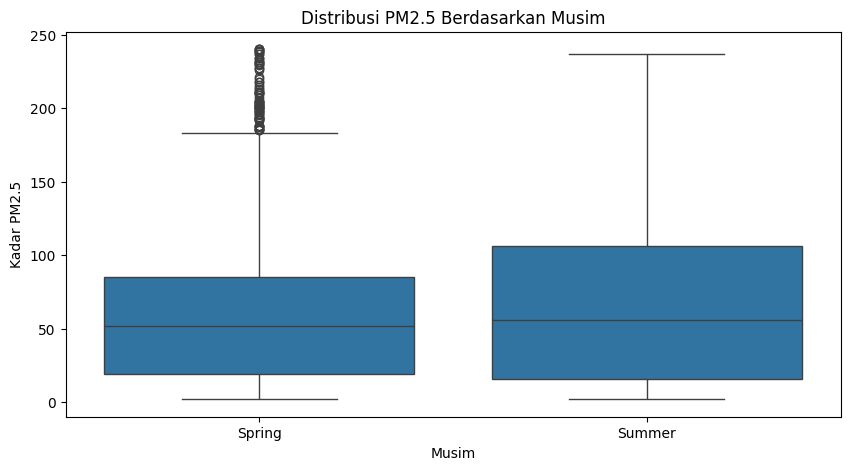

<ipython-input-25-6f4c88553532>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["day_of_week"] = df_filtered["datetime"].dt.day_name()


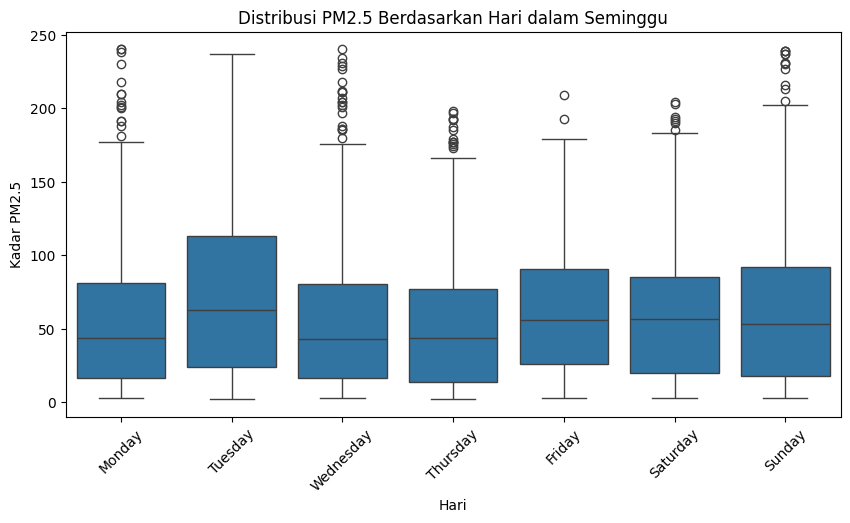

In [ ]:

season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Fall", 10: "Fall", 11: "Fall"}

df_combined["season"] = df_combined["month"].map(season_map)

# **FILTER BERDASARKAN RENTANG WAKTU**
start_year, start_month = 2013, 1
end_year, end_month = 2013, 6

start_date = datetime(start_year, start_month, 1)
end_date = datetime(end_year, end_month, 28)

df_filtered = df_combined[(df_combined["datetime"] >= start_date) &
                          (df_combined["datetime"] <= end_date)]

# **VISUALISASI 1: Distribusi PM2.5 Berdasarkan Musim**
plt.figure(figsize=(10, 5))
sns.boxplot(x="season", y="PM2.5", data=df_filtered)
plt.title("Distribusi PM2.5 Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Kadar PM2.5")
plt.show()

# **VISUALISASI 2: Distribusi PM2.5 Berdasarkan Hari dalam Seminggu**
df_filtered["day_of_week"] = df_filtered["datetime"].dt.day_name()

plt.figure(figsize=(10, 5))
sns.boxplot(x="day_of_week", y="PM2.5", data=df_filtered,
            order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.title("Distribusi PM2.5 Berdasarkan Hari dalam Seminggu")
plt.xlabel("Hari")
plt.ylabel("Kadar PM2.5")
plt.xticks(rotation=45)
plt.show()


winter_df = df_filtered[df_filtered["season"] == "Winter"]

air_quality_params = ["PM2.5", "PM10", "SO2", "NO2", "O3"]

winter_melted = winter_df.melt(id_vars=["PRES"], value_vars=air_quality_params,
                               var_name="Air Quality Parameter", value_name="Value")

# plt.figure(figsize=(12, 6))
# sns.lineplot(x="PRES", y="Value", hue="Air Quality Parameter", data=winter_melted, marker="o")
# plt.title("Tren Kualitas Udara terhadap Tingkat Ketinggian (PRES) di Musim Winter")
# plt.xlab





**Insight:**

### **1. Filter Data**
Data difilter berdasarkan rentang waktu yang telah ditentukan (misalnya, dari tahun 2013 hingga tahun 2015

### **2. Visualisasi Distribusi PM2.5**
Boxplot dibuat untuk memvisualisasikan distribusi PM2.5 berdasarkan musim.

Boxplot juga dibuat untuk memvisualisasikan distribusi PM2.5 berdasarkan hari dalam seminggu.


### **3. Analisis Tren Kualitas Udara terhadap Ketinggian**
Melting digunakan untuk mengubah format data agar sesuai untuk visualisasi tren parameter kualitas udara (PM2.5, PM10, SO2, NO2, O3) terhadap tingkat ketinggian (PRES)

## Visualization & Explanatory Analysis

### Pertanyaan 1:

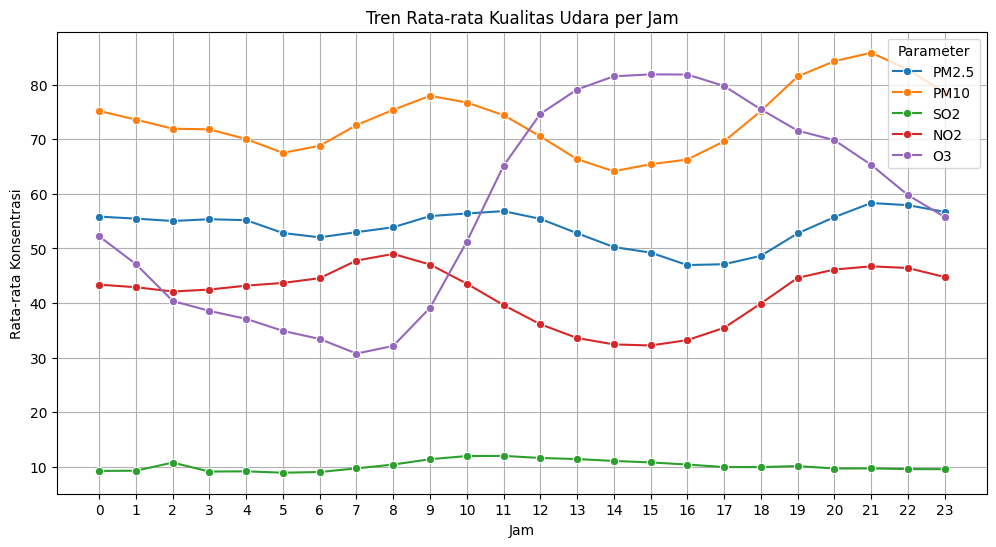

Kualitas udara terburuk untuk PM2.5 terjadi pada jam 21 dengan rata-rata PM2.5: 58.33
Kualitas udara terburuk untuk PM10 terjadi pada jam 21 dengan rata-rata PM10: 85.88
Kualitas udara terburuk untuk SO2 terjadi pada jam 11 dengan rata-rata SO2: 11.99
Kualitas udara terburuk untuk NO2 terjadi pada jam 8 dengan rata-rata NO2: 49.00
Kualitas udara terburuk untuk O3 terjadi pada jam 15 dengan rata-rata O3: 81.91


In [ ]:

avg_hourly = df_combined.groupby(df_combined["datetime"].dt.hour)[air_quality_params].mean()

plt.figure(figsize=(12, 6))
for param in air_quality_params:
    sns.lineplot(x=avg_hourly.index, y=avg_hourly[param], marker='o', label=param)

plt.title("Tren Rata-rata Kualitas Udara per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Konsentrasi")
plt.xticks(range(24))
plt.legend(title="Parameter")
plt.grid(True)
plt.show()

for param in air_quality_params:
    worst_hour = avg_hourly[param].idxmax()
    worst_value = avg_hourly[param].max()
    print(f"Kualitas udara terburuk untuk {param} terjadi pada jam {worst_hour} dengan rata-rata {param}: {worst_value:.2f}")

### Pertanyaan 2:

<ipython-input-27-be88ca93ebdf>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_combined, x="season", y=param, palette="viridis")


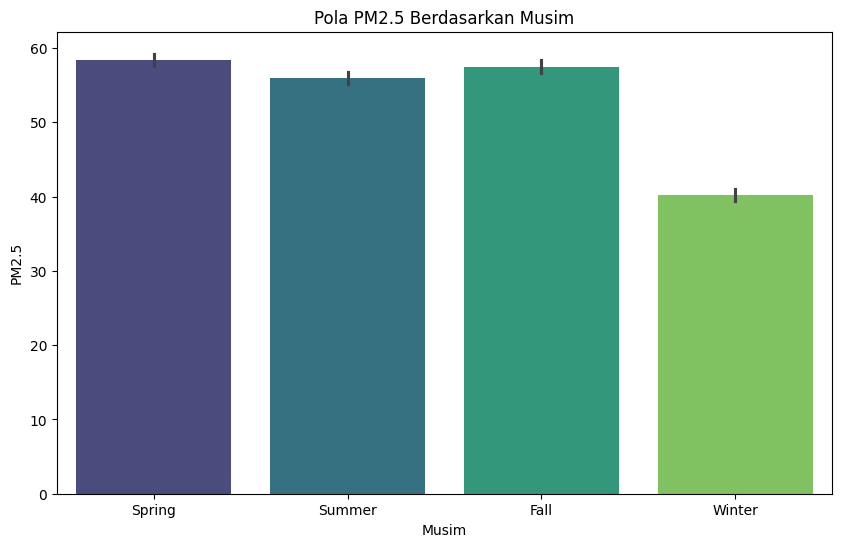


Rata-rata PM2.5 berdasarkan musim:
season
Spring    58.424907
Fall      57.455952
Summer    55.942482
Winter    40.177333
Name: PM2.5, dtype: float64

Kesimpulan: Kadar PM2.5 cenderung paling tinggi pada musim Spring.



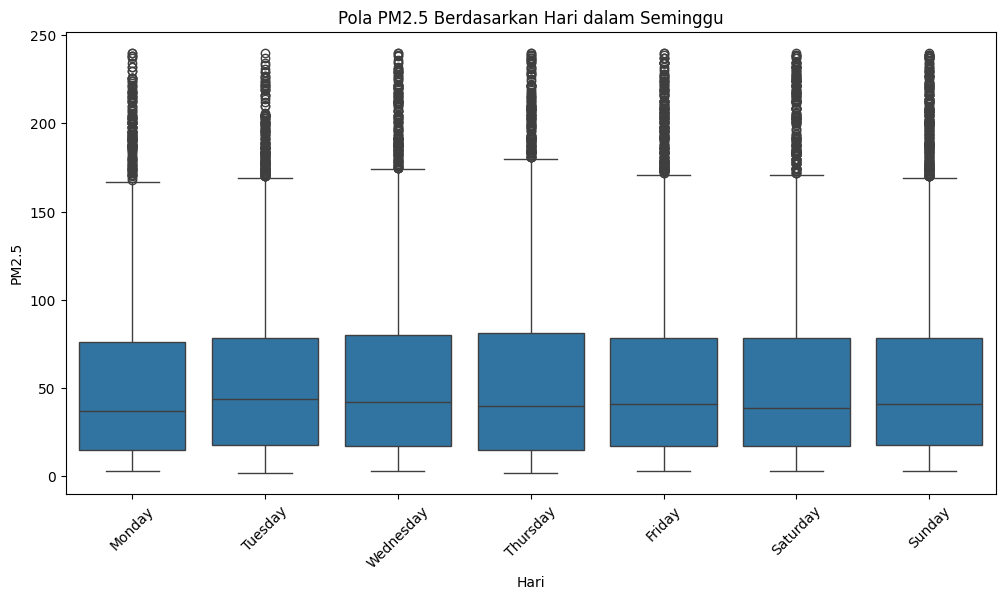


Rata-rata PM2.5 berdasarkan hari dalam seminggu:
day_of_week
Monday       49.986888
Tuesday      54.435599
Wednesday    54.695160
Thursday     55.617606
Friday       54.672817
Saturday     53.431440
Sunday       54.613023
Name: PM2.5, dtype: float64

Kesimpulan: Kadar PM2.5 cenderung paling tinggi pada hari Thursday.



<ipython-input-27-be88ca93ebdf>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_combined, x="season", y=param, palette="viridis")


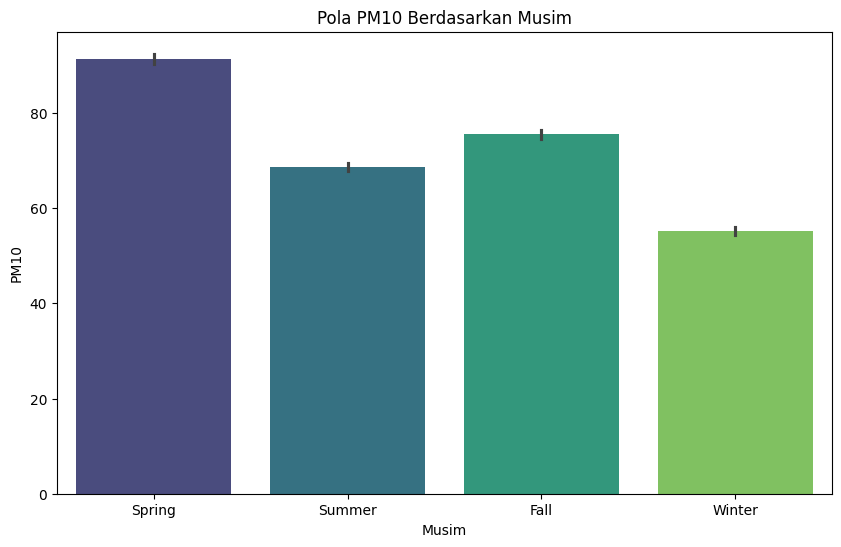


Rata-rata PM10 berdasarkan musim:
season
Spring    91.411653
Fall      75.472718
Summer    68.610690
Winter    55.152146
Name: PM10, dtype: float64

Kesimpulan: Kadar PM10 cenderung paling tinggi pada musim Spring.



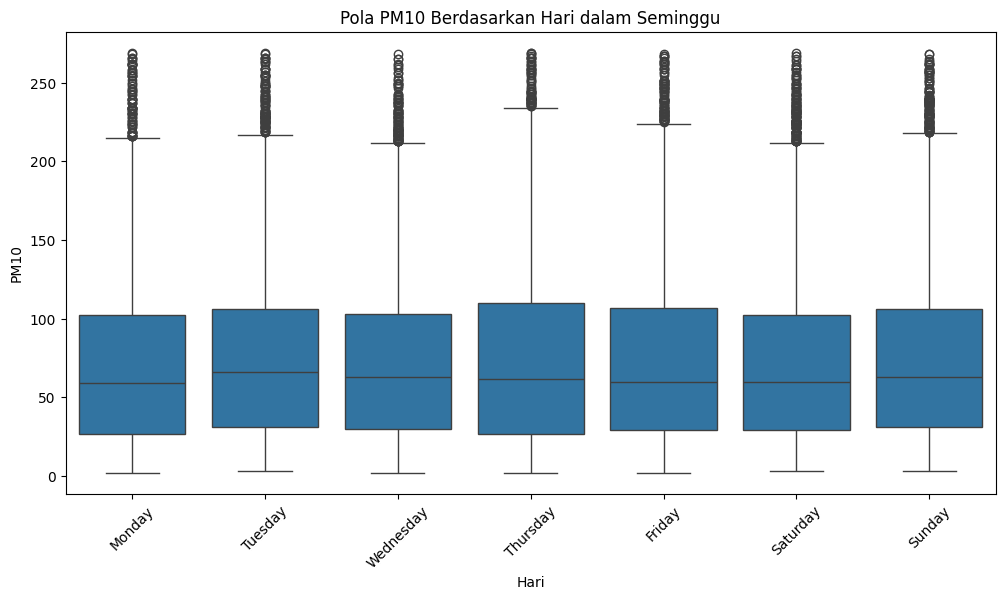


Rata-rata PM10 berdasarkan hari dalam seminggu:
day_of_week
Monday       70.417672
Tuesday      75.226184
Wednesday    73.181241
Thursday     75.009466
Friday       74.600290
Saturday     72.481125
Sunday       75.712659
Name: PM10, dtype: float64

Kesimpulan: Kadar PM10 cenderung paling tinggi pada hari Sunday.



<ipython-input-27-be88ca93ebdf>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_combined, x="season", y=param, palette="viridis")


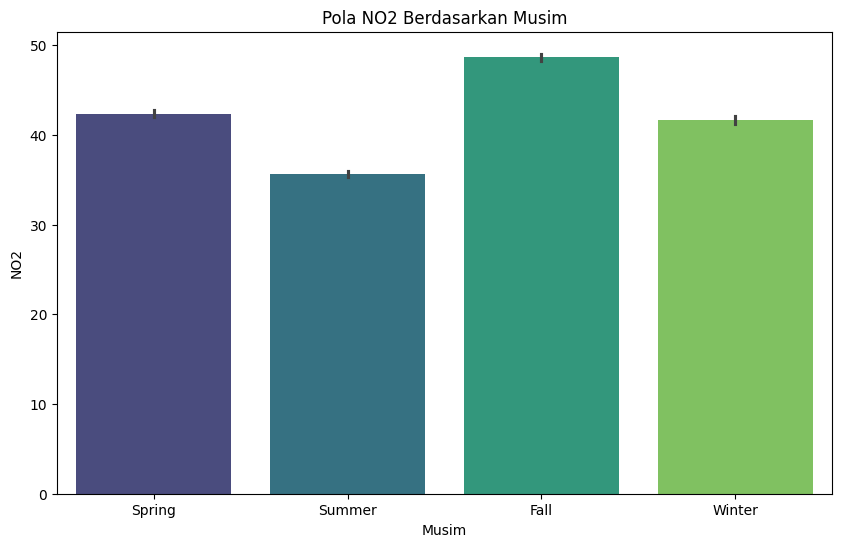


Rata-rata NO2 berdasarkan musim:
season
Fall      48.640887
Spring    42.336897
Winter    41.658070
Summer    35.651417
Name: NO2, dtype: float64

Kesimpulan: Kadar NO2 cenderung paling tinggi pada musim Fall.



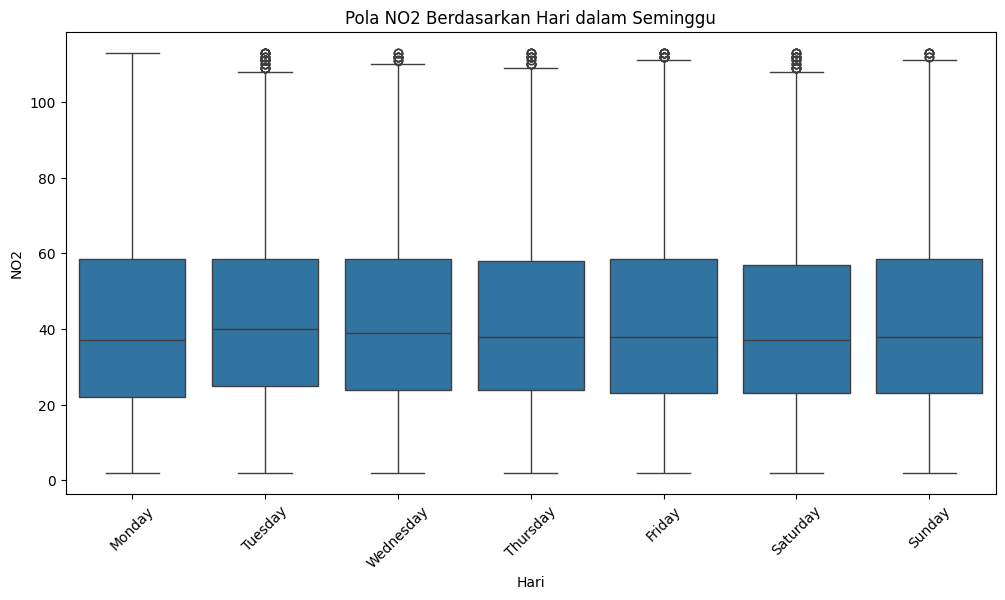


Rata-rata NO2 berdasarkan hari dalam seminggu:
day_of_week
Monday       40.967767
Tuesday      43.603590
Wednesday    42.254697
Thursday     42.260970
Friday       41.954837
Saturday     41.589651
Sunday       41.900035
Name: NO2, dtype: float64

Kesimpulan: Kadar NO2 cenderung paling tinggi pada hari Tuesday.



<ipython-input-27-be88ca93ebdf>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_combined, x="season", y=param, palette="viridis")


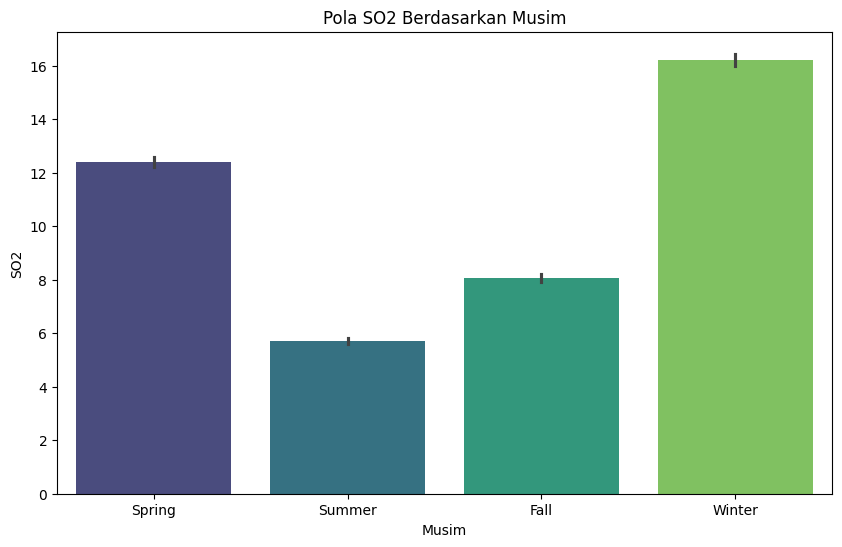


Rata-rata SO2 berdasarkan musim:
season
Winter    16.210608
Spring    12.402847
Fall       8.064932
Summer     5.707522
Name: SO2, dtype: float64

Kesimpulan: Kadar SO2 cenderung paling tinggi pada musim Winter.



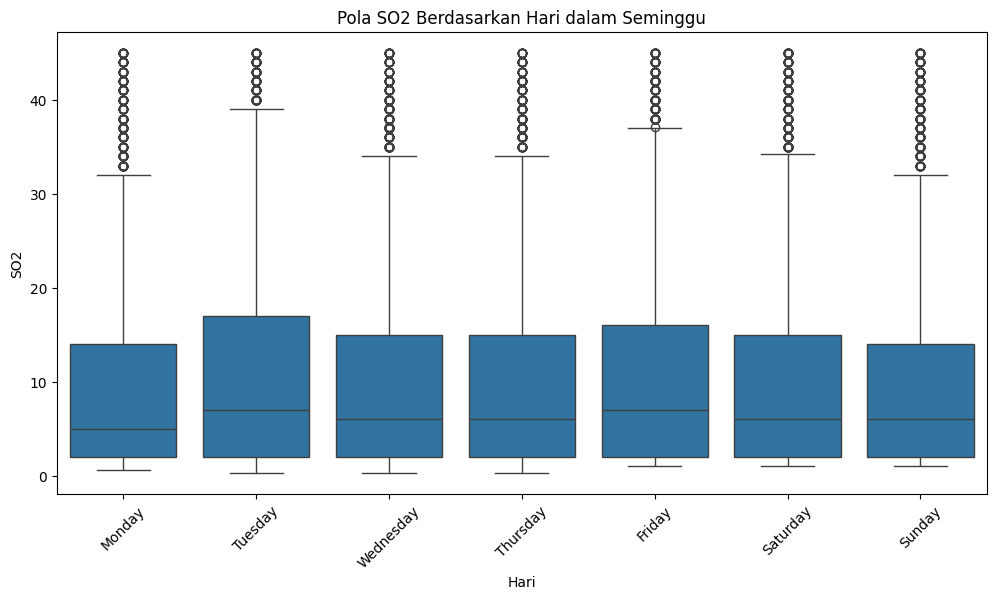


Rata-rata SO2 berdasarkan hari dalam seminggu:
day_of_week
Monday        9.273887
Tuesday      10.833087
Wednesday     9.899433
Thursday      9.942382
Friday       10.893822
Saturday     10.163881
Sunday       10.015034
Name: SO2, dtype: float64

Kesimpulan: Kadar SO2 cenderung paling tinggi pada hari Friday.



<ipython-input-27-be88ca93ebdf>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_combined, x="season", y=param, palette="viridis")


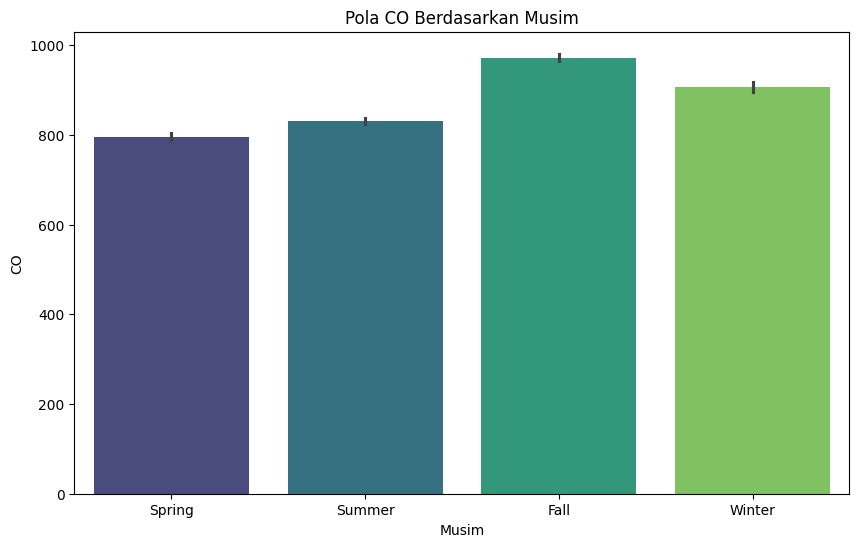


Rata-rata CO berdasarkan musim:
season
Fall      971.523861
Winter    907.355119
Summer    830.548047
Spring    795.685206
Name: CO, dtype: float64

Kesimpulan: Kadar CO cenderung paling tinggi pada musim Fall.



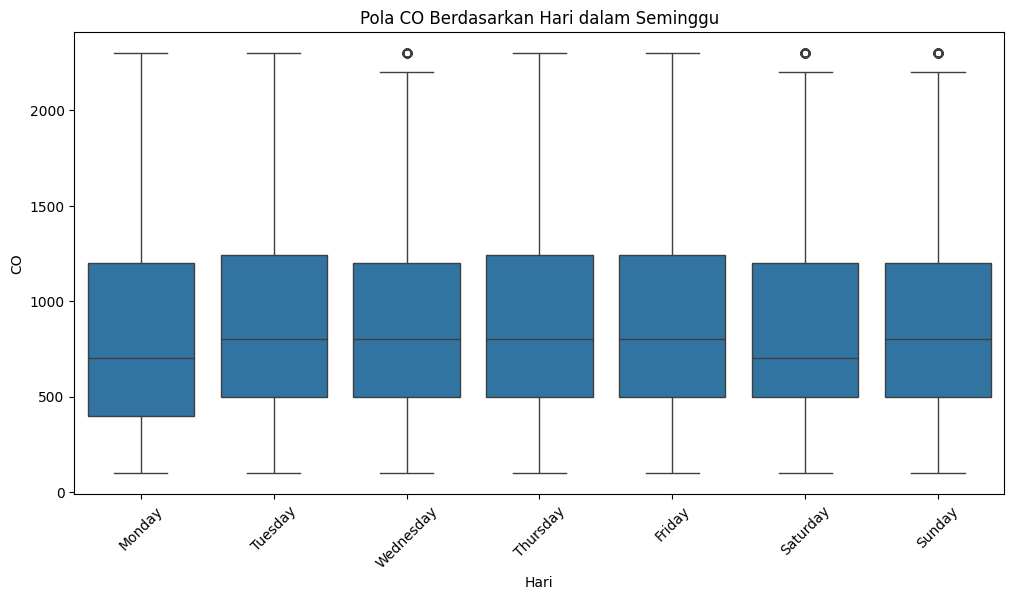


Rata-rata CO berdasarkan hari dalam seminggu:
day_of_week
Monday       836.992934
Tuesday      901.672552
Wednesday    867.078560
Thursday     881.677890
Friday       899.113703
Saturday     858.941529
Sunday       874.764298
Name: CO, dtype: float64

Kesimpulan: Kadar CO cenderung paling tinggi pada hari Tuesday.



<ipython-input-27-be88ca93ebdf>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_combined, x="season", y=param, palette="viridis")


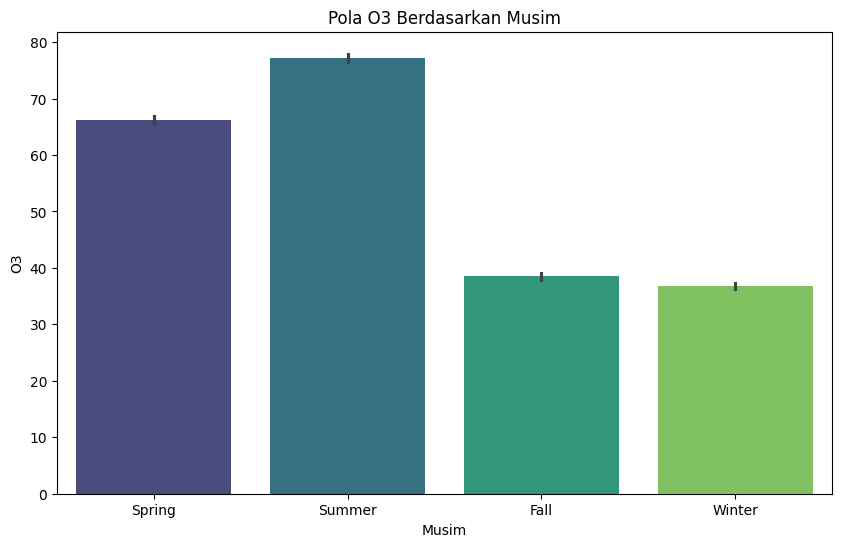


Rata-rata O3 berdasarkan musim:
season
Summer    77.204939
Spring    66.194339
Fall      38.481823
Winter    36.814486
Name: O3, dtype: float64

Kesimpulan: Kadar O3 cenderung paling tinggi pada musim Summer.



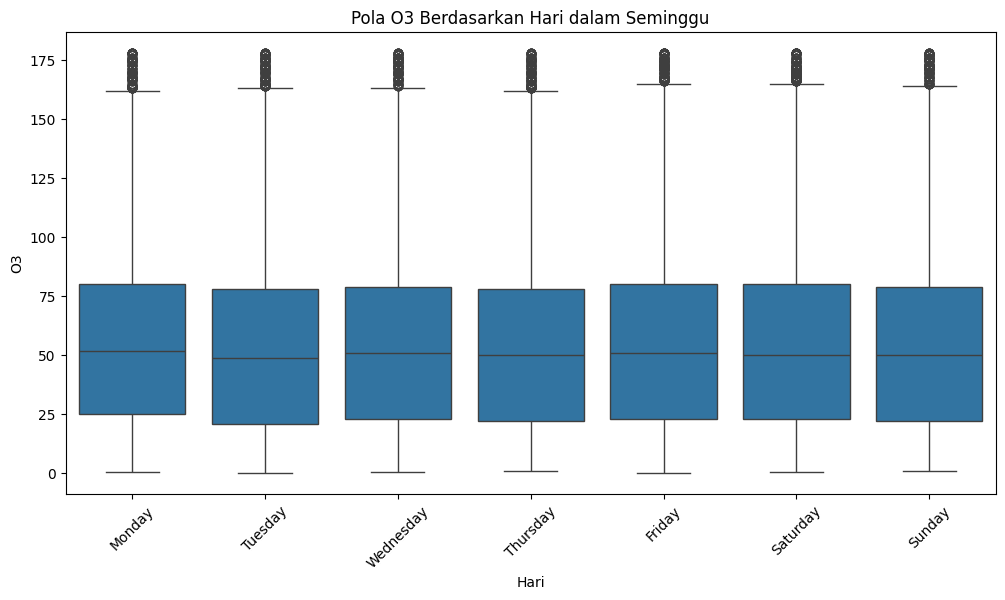


Rata-rata O3 berdasarkan hari dalam seminggu:
day_of_week
Monday       57.312736
Tuesday      54.832979
Wednesday    55.740228
Thursday     55.151068
Friday       55.952240
Saturday     56.771369
Sunday       56.120960
Name: O3, dtype: float64

Kesimpulan: Kadar O3 cenderung paling tinggi pada hari Monday.



In [ ]:
air_quality_param = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]

# # Mapping musim
# season_map = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring",
#               6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall"}
# df_combined["season"] = df_combined["month"].map(season_map)

# df_combined["day_of_week"] = df_combined["datetime"].dt.day_name()

# day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


for param in air_quality_param:

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_combined, x="season", y=param, palette="viridis")
    plt.title(f"Pola {param} Berdasarkan Musim")
    plt.xlabel("Musim")
    plt.ylabel(param)
    plt.show()

    seasonal_avg = df_combined.groupby('season')[param].mean().sort_values(ascending=False)
    print(f"\nRata-rata {param} berdasarkan musim:")
    print(seasonal_avg)

    most_polluted_season = seasonal_avg.index[0]
    print(f"\nKesimpulan: Kadar {param} cenderung paling tinggi pada musim {most_polluted_season}.\n")

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_combined, x="day_of_week", y=param, order=day_order)
    plt.title(f"Pola {param} Berdasarkan Hari dalam Seminggu")
    plt.xlabel("Hari")
    plt.ylabel(param)
    plt.xticks(rotation=45)
    plt.show()

    daily_avg = df_combined.groupby('day_of_week')[param].mean().reindex(day_order)
    print(f"\nRata-rata {param} berdasarkan hari dalam seminggu:")
    print(daily_avg)

    most_polluted_day = daily_avg.idxmax()
    print(f"\nKesimpulan: Kadar {param} cenderung paling tinggi pada hari {most_polluted_day}.\n")
    print("=" * 50)

**Insight:**

### **1. Penghitungan Rata-rata Parameter Kualitas Udara per Jam**
Parameter kualitas udara yang dipilih adalah NO2, namun dapat disesuaikan dengan mengganti parameter pada `selected_param`.
- Rata-rata kadar polutan dihitung per jam menggunakan fungsi `groupby()` dan `mean()`.
- Hasil rata-rata divisualisasikan dengan menggunakan line plot, menunjukkan tren kadar polutan sepanjang hari.

### **2. Identifikasi Jam dengan Kualitas Udara Terburuk**
- Untuk mengidentifikasi jam yang kadar polutannya bernilai tertinggi  menggunakan `idxmax()` dan nilai maksimum diperoleh dengan `max()`.
- Hasilnya dicetak untuk menunjukkan jam di mana kualitas udara terburuk terjadi.

### **3. Pemetaan Musim dan Penambahan Kolom Hari dalam Seminggu**
- Parameter kualitas udara kedua yang dipilih adalah PM2.5, namun bisa disesuaikan pada `selected_param`
- Musim ditentukan berdasarkan bulan menggunakan mapping yang telah dibuat sebelumnya.
-  Menambahkan kolom `day_of_week` untuk menyimpan nama hari dari kolom datetime.

### **4. Visualisasi Pola Musiman Kadar Polutan**
- Pola kadar polutan berdasarkan musim divisualisasikan menggunakan bar plot.
- Rata-rata kadar polutan dihitung untuk setiap musim dan ditampilkan dalam grafik.
- Musim dengan kadar polutan tertinggi dicetak sebagai kesimpulan.

### **5. Visualisasi Pola Harian Kadar Polutan**
- Pola kadar polutan berdasarkan hari dalam seminggu divisualisasikan menggunakan box plot.
- Urutan hari ditentukan untuk memastikan tampilan yang konsisten.
- Rata-rata kadar polutan dihitung untuk setiap hari dalam seminggu dan diatur sesuai urutan hari.
- Hari dengan kadar polutan tertinggi diidentifikasi dan dicetak sebagai kesimpulan.

## Analisis Lanjutan (Opsional)

<ipython-input-28-cfe672c5e284>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Cluster"] = kmeans.fit_predict(df_scaled)


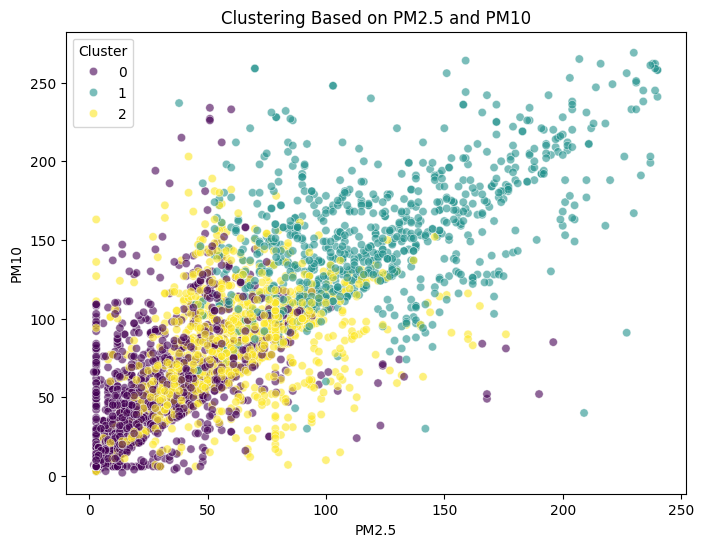

Cluster Distribution:
      station  PM2.5   PM10   SO2   NO2     CO    O3  Cluster
0   Changping    3.0    6.0  13.0   7.0  300.0  85.0        0
1   Changping    3.0    3.0   6.0   6.0  300.0  85.0        0
2   Changping    3.0    3.0  22.0  13.0  400.0  74.0        0
3   Changping    3.0    6.0  12.0   8.0  300.0  81.0        0
4   Changping    3.0    3.0  14.0   8.0  300.0  81.0        0
5   Changping    3.0    3.0  10.0  17.0  400.0  71.0        0
6   Changping    4.0    6.0  12.0  22.0  500.0  65.0        0
7   Changping    3.0    6.0  25.0  39.0  600.0  48.0        0
8   Changping    9.0   25.0  13.0  42.0  700.0  46.0        0
9   Changping   11.0   29.0   5.0  18.0  500.0  73.0        0
10  Changping    9.0   10.0   3.0  10.0  300.0  83.0        0
11  Changping    3.0    3.0   4.0   9.0  300.0  81.0        0
12  Changping    3.0    6.0   4.0   8.0  300.0  90.0        0
13  Changping    3.0  101.0   5.0   9.0  300.0  89.0        0
14  Changping    9.0   60.0   5.0   6.0  300.0  

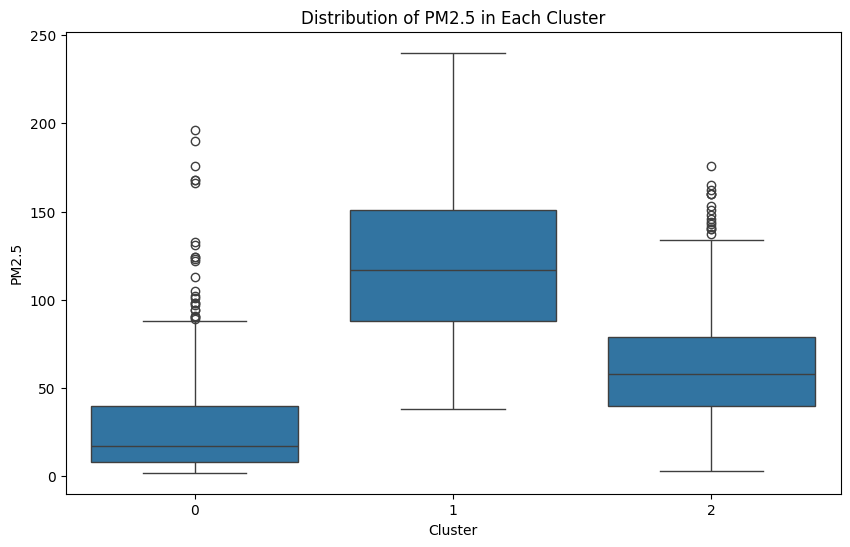

In [ ]:
clustering_features = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
df_clustering = df_filtered[clustering_features].dropna()

# Data scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_filtered["Cluster"] = kmeans.fit_predict(df_scaled)

# Visualizations (using Matplotlib and Seaborn)

# Scatter plot of PM2.5 vs PM10, colored by cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_filtered["PM2.5"], y=df_filtered["PM10"], hue=df_filtered["Cluster"], palette="viridis", alpha=0.6)
plt.xlabel("PM2.5")
plt.ylabel("PM10")
plt.title("Clustering Based on PM2.5 and PM10")
plt.show()

# Display cluster distribution
print("Cluster Distribution:")
print(df_filtered[["station", "PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "Cluster"]].head(20))

# Boxplot of PM2.5 distribution in each cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_filtered["Cluster"], y=df_filtered["PM2.5"])
plt.title("Distribution of PM2.5 in Each Cluster")
plt.show()

### **1. Penskalaan Data**
- Data dinormalisasi menggunakan `StandardScaler` untuk memastikan bahwa semua fitur memiliki skala yang sama.
- Hasil penskalaan disimpan dalam variabel `df_scaled`.

### **2. K-Means Clustering**
- Algoritma K-Means dipilih untuk mengelompokkan data ke dalam 3 cluster (`n_clusters=3`).
- Parameter `random_state=42` digunakan untuk memastikan hasil yang konsisten pada saat kode dijalankan.
- Hasil clustering ditambahkan ke dataframe `df_filtered` dalam kolom baru bernama **Cluster**.

### **4. Visualisasi Hasil Clustering (Scatter Plot)**
- Scatter plot dibuat untuk memvisualisasikan hubungan antara PM2.5 dan PM10.
- Setiap titik berwarna sesuai dengan cluster yang ditentukan, memberikan gambaran visual tentang distribusi data antar cluster.

### **5. Distribusi Cluster**
- Informasi mengenai distribusi cluster ditampilkan dengan mencetak 20 baris pertama dari dataframe.
- Data ini mencakup informasi stasiun, kadar polutan (PM2.5, PM10, SO2, NO2, CO, O3), dan cluster.

### **6. Visualisasi Distribusi PM2.5 dalam Setiap Cluster**
- Boxplot dibuat untuk menunjukkan distribusi kadar PM2.5 di setiap cluster.
- Visualisasi ini dibuat untuk membantu memahami perbedaan kadar PM2.5 di antara cluster yang telah terbentuk.

## Conclusion

# **Kesimpulan Analisis Kualitas Udara di Changping dan Dongsi**



Dari hasil analisis data, ditemukan beberapa pola penting terkait perubahan kualitas udara di kedua kota ini:

# **Pada jam berapa kualitas udara di Kota Changping dan Dongsi memburuk dari biasanya?**

### **1. Jam-Jam dengan Polusi Tinggi**
- terdapat jam-jam tertentu di mana kadar polutan meningkat secara signifikan.
- Tren ini diduga akibat aktivitas kendaraan dan industri saat jam sibuk.

### **2. Perbedaan Polusi Berdasarkan Hari dalam Seminggu**
- Polusi udara lebih tinggi pada hari kerja dibandingkan akhir pekan, menunjukkan pengaruh besar dari aktivitas industri dan lalu lintas.
- Namun, ada kemungkinan peningkatan polusi pada akhir pekan di lokasi tertentu, akibat aktivitas rekreasi dan mobilitas penduduk.

# **Bagaimana pola perubahan kualitas udara berdasarkan musim atau hari dalam seminggu?**

### **3. Perubahan Kualitas Udara Berdasarkan Musim**
- Musim dingin cenderung memiliki tingkat polusi yang lebih tinggi dibandingkan musim lainnya.
- Faktor utama yang memengaruhi adalah pemanasan rumah tangga, perubahan atmosfer, serta peningkatan emisi.


### **4. Perbandingan Kualitas Udara di Changping dan Dongsi**
- Dari hasil analisis, dapat terlihat bahwa salah satu kota memiliki kualitas udara lebih buruk dibanding yang lain.
- Clustering K-Means membagi wilayah berdasarkan tingkat polusi: rendah, sedang, dan tinggi.

--------

Hasil analisis ini menunjukkan bahwa kualitas udara di Changping dan Dongsi dipengaruhi oleh waktu, musim, dan aktivitas manusia. Data ini dapat digunakan untuk:
1. Membantu pengambilan kebijakan seperti pembatasan kendaraan di jam sibuk.
2. Menentukan strategi mitigasi polusi pada musim tertentu.
3. Mengoptimalkan sistem transportasi ramah lingkungan untuk mengurangi emisi.